<a href="https://colab.research.google.com/github/sharifa-15/diabetes-prediction/blob/main/Diabetics_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [9]:
from google.colab import files
uploaded = files.upload()


Saving diabetes.csv to diabetes.csv


In [10]:
import pandas as pd

df = pd.read_csv("diabetes.csv")
print(df.head())


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [11]:

# 3. Preprocessing
cols_with_missing = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for col in cols_with_missing:
    df[col] = df[col].replace(0, df[col].median())

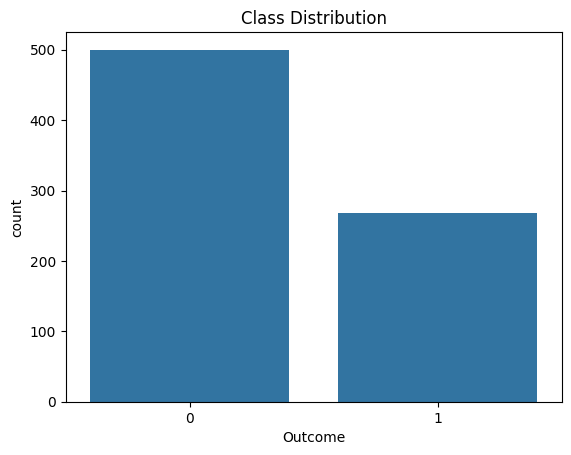

In [12]:
# 4. Exploratory Data Analysis (EDA)
# Class balance
sns.countplot(x="Outcome", data=df)
plt.title("Class Distribution")
plt.show()

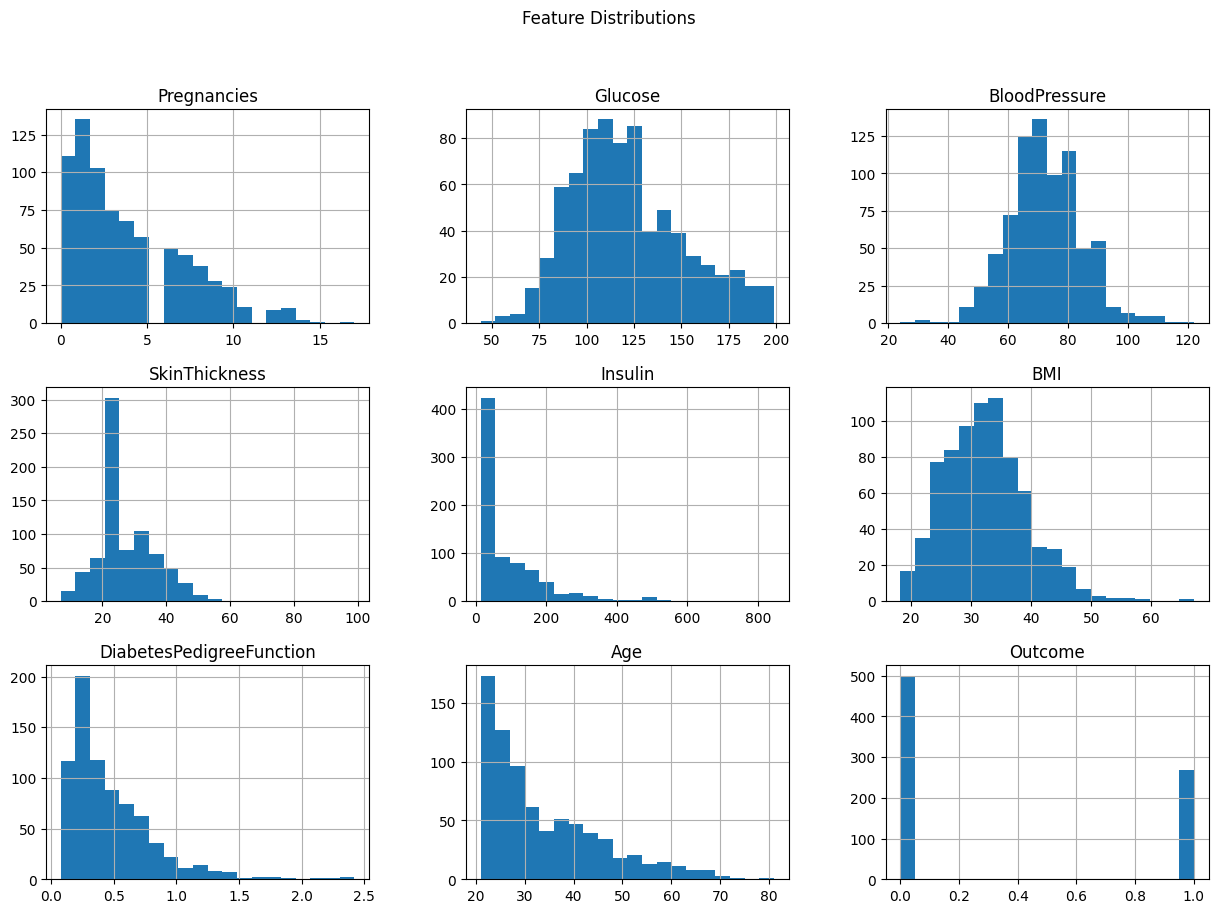

In [13]:

# Histograms
df.hist(bins=20, figsize=(15,10))
plt.suptitle("Feature Distributions")
plt.show()

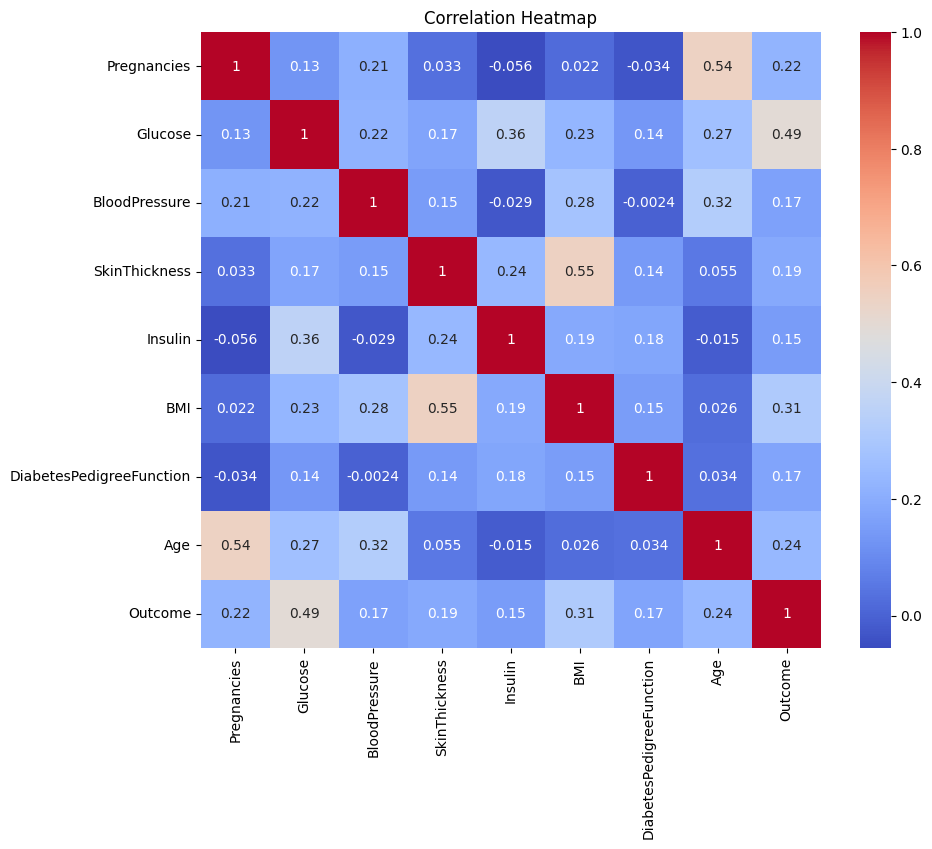

In [14]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [15]:

# 5. Features & Target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [16]:
# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
# 6. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 7. Model Training
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

              precision    recall  f1-score   support

           0       0.82      0.81      0.81        99
           1       0.66      0.67      0.67        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154

ROC-AUC: 0.7404040404040404


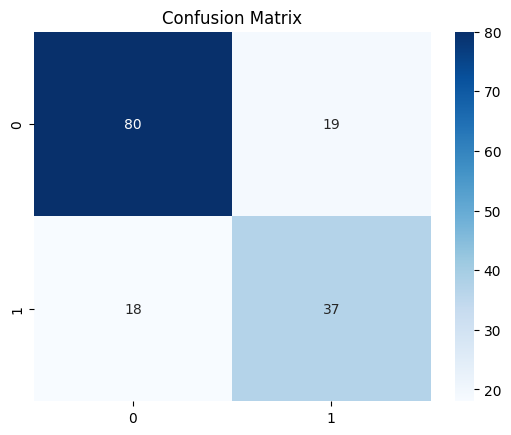

In [18]:

# 8. Evaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

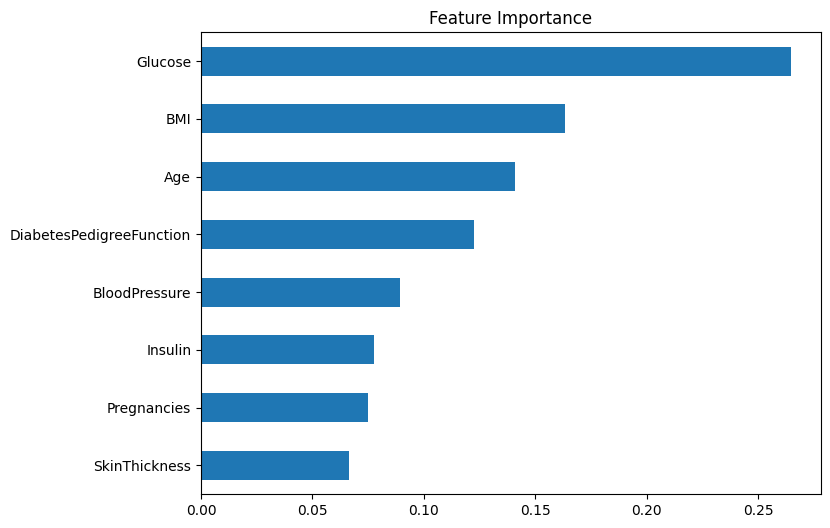

In [19]:

# 9. Feature Importance
importances = model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)
feat_importances.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance")
plt.show()